<a href="https://colab.research.google.com/github/YardenGoraly/Mujoco_fun/blob/main/MuJoCo_fun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
#Initial setup, you shouldn't have to modify this code

%pip install -qq mujoco
%pip install -qq mediapy

import platform
import os
import subprocess
import mediapy as media

# Detect the operating system and configure GPU rendering accordingly.
if platform.system() == "Linux":
    # Assume Nvidia GPU is present.
    if subprocess.run("nvidia-smi", shell=True).returncode != 0:
        raise RuntimeError(
            "Cannot communicate with GPU. Make sure you are using a GPU runtime."
        )

    # Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
    NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
    if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
        with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
            f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")
    print("Setting environment variable for Nvidia GPU rendering (EGL).")
    os.environ["MUJOCO_GL"] = "egl"

elif platform.system() == "Darwin":
    # Assume running on macOS (Apple Silicon).
    print("Running on macOS. Setting environment variable for GPU rendering using GLFW.")
    os.environ["MUJOCO_GL"] = "glfw"

    media.set_ffmpeg("/opt/homebrew/bin/ffmpeg")
else:
    print("Unsupported platform. GPU rendering might not be configured correctly.")

# Check if MuJoCo installation was successful.
try:
    import mujoco as mj
    mj.MjModel.from_xml_string("<mujoco/>")
except Exception as e:
    raise RuntimeError(
        "Something went wrong during MuJoCo installation. Check the shell output above for more information."
    ) from e

print("MuJoCo installation successful.")

# Other imports and helper functions.
import time
import itertools
import numpy as np
np.set_printoptions(precision=3, suppress=True, linewidth=100)

# Graphics and plotting.
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# On Linux, ensure ffmpeg is installed (this is not applicable on macOS).
if platform.system() == "Linux":
    !command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)

%pip install -q mediapy
import mediapy as media

from IPython.display import clear_output
clear_output()


In [78]:
#More setup 
%pip install -qq robot_descriptions
%pip install -qq dm_control

from robot_descriptions import panda_mj_description
from IPython.display import HTML
# this is loading from mujoco, one of the custom loaders of robot_descriptions
# the others are pybullet, iDynTree, Pinocchio, RoboMeshCat, yourdfpy
from robot_descriptions.loaders.mujoco import load_robot_description
from dm_control import mjcf
import dm_control
import PIL.Image


def display_video(frames, framerate=30):
    height, width, _ = frames[0].shape
    dpi = 70
    orig_backend = matplotlib.get_backend()
    matplotlib.use('Agg')  # Switch to headless 'Agg' to inhibit figure rendering.
    fig, ax = plt.subplots(1, 1, figsize=(width / dpi, height / dpi), dpi=dpi)
    matplotlib.use(orig_backend)  # Switch back to the original backend.
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_position([0, 0, 1, 1])
    im = ax.imshow(frames[0])
    def update(frame):
      im.set_data(frame)
      return [im]
    interval = 1000/framerate
    anim = animation.FuncAnimation(fig=fig, func=update, frames=frames,
                                   interval=interval, blit=True, repeat=False)
    return HTML(anim.to_html5_video())


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [79]:
# Get XML for Sawyer, hand, and ball
ball_xml = """
<mujoco model="ball">
    <worldbody>
        <body name="ball_body" pos="1.0 -0.2 0.95">
            <geom name="ball_geom" mass="0.01" friction="1.5" type="sphere" size="0.05" rgba="1 0 0 1"
                  solref="0.06 1" solimp="0.9 0.95 0.003 0.5 2"/>
        </body>
    </worldbody>
</mujoco>
"""

table_xml = """
<mujoco model="table">
    <worldbody>
        <body name="table_body" pos="1.0 -0.2 0.45">
            <geom name="table_geom" mass="200000" friction="0.8" type="box" solref="0.01 0.5" size="0.3 0.6 0.45" rgba="0.798 0.71 0.469 1"/>
        </body>
    </worldbody>
</mujoco>
"""

hand_path = "mujoco_menagerie/wonik_allegro/right_hand.xml"
sawyer_path = "mujoco_menagerie/rethink_robotics_sawyer/sawyer.xml"

In [80]:
# Define Models
hand_model = mjcf.from_path(hand_path)
sawyer_model = mjcf.from_path(sawyer_path)
ball_model = mjcf.from_xml_string(ball_xml)
table_model = mjcf.from_xml_string(table_xml)

ball_geom = ball_model.find('geom', 'ball_geom')
print(ball_geom.name)   # ball_geom

# Fingertips in XML are not actually at the tip, so we add a body with an offset
ff_tip = hand_model.find('body', 'ff_tip')
ff_tip.add('body', name='ff_tip_rubber', pos=[0, 0, 0.028])
hand_model.find('body', 'ff_tip_rubber').add('geom', type='sphere', size=[0.012], rgba=[0, 0, 0, 0])
mf_tip = hand_model.find('body', 'mf_tip')
mf_tip.add('body', name='mf_tip_rubber', pos=[0, 0, 0.028])
hand_model.find('body', 'mf_tip_rubber').add('geom', type='sphere', size=[0.012], rgba=[0, 0, 0, 0])
rf_tip = hand_model.find('body', 'rf_tip')
rf_tip.add('body', name='rf_tip_rubber', pos=[0, 0, 0.028])
hand_model.find('body', 'rf_tip_rubber').add('geom', type='sphere', size=[0.012], rgba=[0, 0, 0, 0])
th_tip = hand_model.find('body', 'th_tip')
th_tip.add('body', name='th_tip_rubber', pos=[0, 0, 0.044])
hand_model.find('body', 'th_tip_rubber').add('geom', type='sphere', size=[0.012], rgba=[0, 0, 0, 0])

ball_geom


MJCF Element: <geom type="sphere" size="0.012" rgba="0 0 0 0"/>

In [81]:
# Attach hand to the Sawyer
arena = mjcf.RootElement()
sawyer_site = sawyer_model.find('site', 'attachment_site')
attachment_frame = arena.attach(ball_model)
arena.attach(table_model)
sawyer_site.attach(hand_model)
arena.attach(sawyer_model)

# Set up scene
sky = arena.asset.add('texture', type='skybox', builtin="gradient", rgb1=[0, .2, 1], 
                      rgb2="1 1 1", width=512, height=512)
chequered = arena.asset.add('texture', type='2d', builtin='checker', width=500,
                            height=500, rgb1=[.2, .3, .4], rgb2=[.3, .4, .5])
grid = arena.asset.add('material', name='grid', texture=chequered,
                       texrepeat=[30, 30], reflectance=.1)
arena.worldbody.add('geom', type='plane', size=[10, 10, 10], material=grid)
for x in [-2, 2]:
  arena.worldbody.add('light', pos=[x, -1, 3], dir=[-x, 1, -2])
for y in [-2, 2]:
  arena.worldbody.add('light', pos=[-1, y, 3], dir=[1, -y, -2], attenuation=[3, 0, 0], castshadow=False)
arena.worldbody.add('camera', name='camera_1', pos=[-1, -1, 0.3], euler=[1.55, 2, 0])

# Add freejoint to ball so it can move freely
attachment_frame.add('joint', name='ball_joint', type='free', armature='5e-5')

# Extract ball elements to read attributes
ball_body = ball_model.find('body', 'ball_body')
ball_geom = ball_model.find('geom', 'ball_geom')

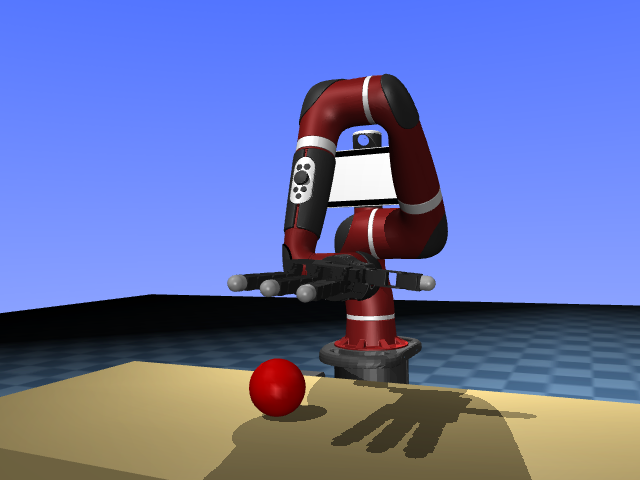

In [82]:
def set_camera_position(physics, camera_name, camera_position):
    camera_id = physics.model.name2id(camera_name, "camera")
    physics.named.model.cam_pos[camera_name] = camera_position
    return camera_id

def set_initial_configuration():
    initial_qpos = [0, 0, 0, 0, 0, 0, 0, 0, -0.8, 0, 2, 0, -1.2, 3.2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    physics.data.qpos[:] = initial_qpos

physics = mjcf.Physics.from_mjcf_model(arena)

# Init scene
camera_id1 = set_camera_position(physics, "camera_1", [1.9, 0.3, 1.2])
set_initial_configuration()

physics.forward()
PIL.Image.fromarray(physics.render(height=480, width=640, camera_id=camera_id1))

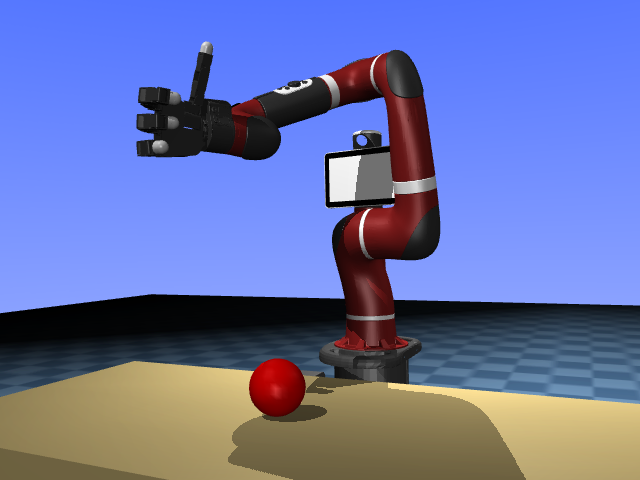

In [83]:
# Task 1:
import importlib
import multifingered_ik

importlib.reload(multifingered_ik)

from multifingered_ik import LevenbergMarquardtIK

def evaluate_IK(physics, target_positions, target_orientations, target_names):
    """
    This function evaluates the IK solver for the target bodies.
    """
    model = physics.model
    data = physics.data
    step_size = 0.5
    tol = 0.002
    alpha = 0.5
    n = len(target_positions)
    jacp = np.zeros((n, 3, model.nv)) #translational Jacobian
    jacr = np.zeros((n, 3, model.nv)) #rotational Jacobian
    damping = 0.15
    max_steps = 200

    ik = LevenbergMarquardtIK(model, data, step_size, tol, alpha, jacp, jacr, damping, max_steps, physics)
    final_qpos = ik.calculate(target_positions, target_orientations, target_names)
    return final_qpos

# YOUR CODE HERE: Fill these in from lab doc
target_positions = [
    [1.0139, -0.4455, 1.4342], 
    [1.0566, -0.3681, 1.4689], 
    [1.0564, -0.3731, 1.4255], 
    [1.0765, -0.3651, 1.3784], 
    [0.9403, -0.4003, 1.6041]
]

target_orientations = [
    [-0.62, -0.588, -0.3918, -0.3287], 
    [0.3301, 0.305, -0.6762, -0.5838], 
    [0.3465, 0.2863, -0.6522, -0.6104], 
    [0.0174, -0.0705, -0.7239, -0.686],
    [-0.9672, 0.061, 0.0294, 0.2446]
]

target_names = [
    'sawyer/allegro_right/palm', 
    'sawyer/allegro_right/ff_tip_rubber',
    'sawyer/allegro_right/mf_tip_rubber', 
    'sawyer/allegro_right/rf_tip_rubber',
    'sawyer/allegro_right/th_tip_rubber'
]

physics.reset()
final_qpos = evaluate_IK(physics, target_positions, target_orientations, target_names)
physics.data.qpos[:] = final_qpos
physics.forward()
PIL.Image.fromarray(physics.render(height=480, width=640, camera_id=camera_id1))

In [84]:
# Task 2:
# Note: your solution to task 1 must be correct for this starter code to work

# Setting up initial hand configuration for grasp
physics.reset()
# Set palm target state
target_palm_position = ball_body.pos
target_palm_position[2] += 0.1
# target_palm_position[2] += 0.05
target_palm_position = target_palm_position.reshape(1, -1)
target_palm_orientation = np.array([[0.71, 0, 0.71, 0]])
target_name = ['sawyer/allegro_right/palm']

# Solve IK on palm
set_initial_configuration()
palm_qpos_IK = evaluate_IK(physics, target_palm_position, target_palm_orientation, target_name)
physics.data.qpos = palm_qpos_IK
physics.data.qpos[14:] = 0
physics.forward()
PIL.Image.fromarray(physics.render(height=480, width=640, camera_id=camera_id1))
base_qpos = physics.data.qpos.copy()


In [85]:
from AllegroHandEnv import AllegroHandEnvSphere

import importlib
import grasp_synthesis
importlib.reload(grasp_synthesis)

# After you make changes to synthesize_grasp

# Reset to the base position
physics.reset()
physics.data.qpos[:] = base_qpos
physics.forward()

# Run grasp synthesis algorithm and keep intermediate joint states for visualization
q_h_slice = slice(14, 30)
q_h_init = physics.data.qpos[q_h_slice]
object_name = 'ball/ball_geom'
ball_radius = ball_geom.size[0]
ball_center = np.array(ball_body.pos)

allegro_env = AllegroHandEnvSphere(physics, ball_center, ball_radius, q_h_slice, object_name)
fingertip_names = ['sawyer/allegro_right/ff_tip_rubber', 'sawyer/allegro_right/mf_tip_rubber', 'sawyer/allegro_right/rf_tip_rubber', 'sawyer/allegro_right/th_tip_rubber']
force_closure_q_h, grasp_history = grasp_synthesis.synthesize_grasp(
    allegro_env,
    q_h_init,
    fingertip_names,
    return_history=True,
    max_iters=2000,
    lr=0.1,
 )

print(f"Saved {len(grasp_history)} grasp states for formation video.")

contacted_fingers: [0 0 0 0] distances: [0.085 0.076 0.084 0.129]
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
Iter 0, objective=0.4791, improvement=0.0251
contacted_fingers: [0 0 0 0] dista

In [86]:
# Render a video of grasp formation from optimization history
formation_video = []

# Keep arm/base joints fixed at the state used for grasp synthesis
base_qpos = physics.data.qpos.copy()

# Optional contact visualization for debugging
formation_options = mj.MjvOption()
mj.mjv_defaultOption(formation_options)
formation_options.flags[mj.mjtVisFlag.mjVIS_CONTACTPOINT] = False
formation_options.flags[mj.mjtVisFlag.mjVIS_CONTACTFORCE] = False
formation_options.flags[mj.mjtVisFlag.mjVIS_TRANSPARENT] = False

with mj.Renderer(physics.model.ptr, 480, 640) as renderer:
    for q_h in grasp_history:
        physics.data.qpos[:] = base_qpos
        physics.data.qpos[q_h_slice] = q_h
        physics.forward()

        renderer.update_scene(physics.data.ptr, "camera_1", formation_options)
        formation_video.append(renderer.render())

media.show_video(formation_video, fps=20)

# Leave simulation at final synthesized grasp
physics.data.qpos[q_h_slice] = force_closure_q_h
physics.data.qvel[:] = 0
physics.forward()

print("matches?", np.allclose(physics.data.qpos[q_h_slice], force_closure_q_h))
# physics.data.qpos[q_h_slice] = force_closure_q_h
physics.forward()

This browser does not support the video tag.


matches? True


""

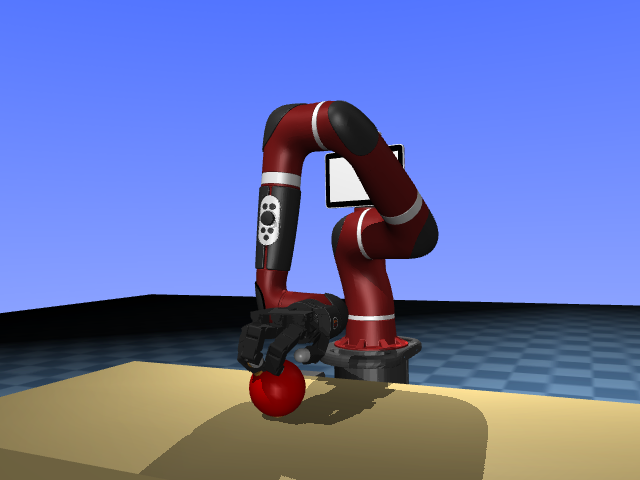

In [87]:
# Here are some flags you can set to visualize contact forces
# We suggest that you visualize the results of your grasp synthesis algorithm when debugging
# Visualize contact frames and forces, make body transparent

# Reset to the base position
physics.reset()
physics.data.qpos[:] = base_qpos
physics.forward()


options = mj.MjvOption()
mj.mjv_defaultOption(options)
options.flags[mj.mjtVisFlag.mjVIS_CONTACTPOINT] = True
options.flags[mj.mjtVisFlag.mjVIS_CONTACTFORCE] = False
options.flags[mj.mjtVisFlag.mjVIS_TRANSPARENT] = False

# tweak scales of contact visualization elements
physics.model.ptr.vis.scale.contactwidth = 0.1
physics.model.ptr.vis.scale.contactheight = 0.03
physics.model.ptr.vis.scale.forcewidth = 0.05
physics.model.ptr.vis.map.force = 0.05

# Take the full qpos for our force closure grasp for later
grasp_q = physics.data.qpos.copy()

# Show hand in grasp configuration
with mj.Renderer(physics.model.ptr, 480, 640) as renderer:
    renderer.update_scene(physics.data.ptr, "camera_1", options)
    frame = renderer.render()
    media.show_image(renderer.render())

Physics error at step 7: Physics state is invalid. Warning(s) raised: mjWARN_BADQACC
qpos: [-0.     0.    -0.     1.     0.     0.     0.    -0.     0.     0.     0.    -0.     0.     0.
 -0.     0.     0.     0.    -0.     0.     0.     0.    -0.     0.     0.     0.     0.002  0.
 -0.    -0.   ]
qvel: [-0.     0.    -0.001  0.     0.001  0.    -0.     0.022  0.004  0.003 -0.     0.     0.001 -0.
  0.001  0.     0.    -0.     0.001  0.     0.    -0.     0.001  0.     0.     1.232  0.    -0.
 -0.   ]
ctrl: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
ncon: 1
Exiting loop early due to invalid state.


Text(0, 0.5, 'Newton')

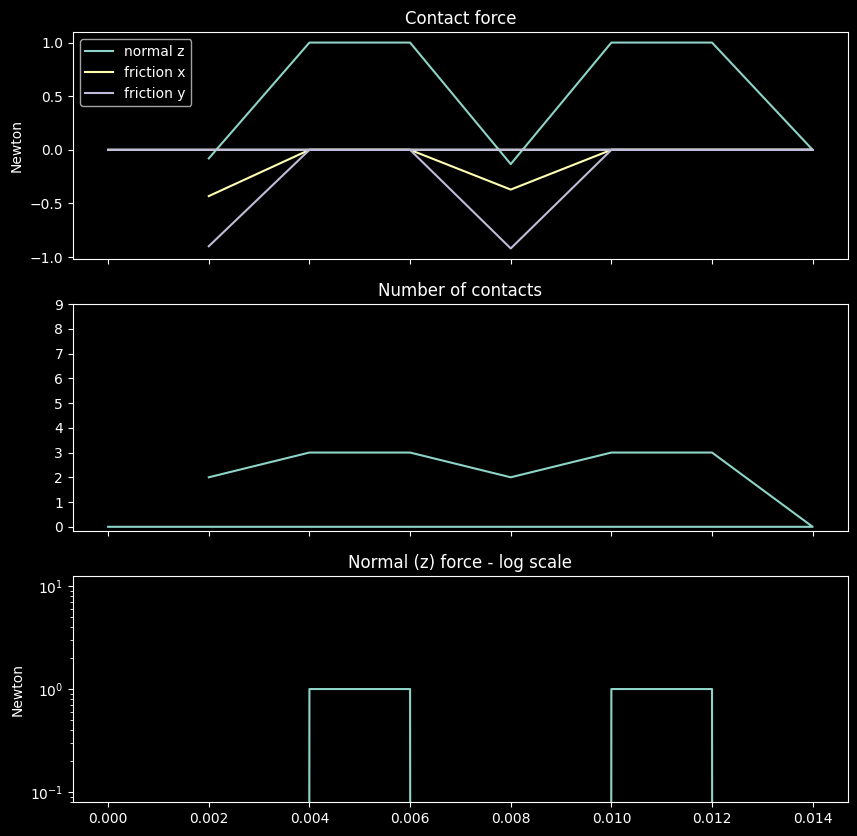

In [88]:
# --- CONTROL LOOP WITH DIAGNOSTICS ---
duration = 5
framerate = 30
n_steps = duration * framerate
dt = 1 / framerate
video = []
n_steps = int(n_steps)
sim_time = np.zeros(n_steps)
ncon = np.zeros(n_steps)
force = np.zeros((n_steps,3))
forcetorque = np.zeros(6)
arm_slice = slice(0, 14)  # Sawyer arm joints
hand_slice = slice(14, 30)  # Allegro hand joints

# Get initial and target palm pose
init_qpos = grasp_q.copy()
palm_body = physics.named.data.xpos['sawyer/allegro_right/palm'].copy()
palm_pos_init = palm_body.copy()
palm_pos_target = palm_body.copy()
palm_pos_target[2] += 0.10  # Raise palm by 10cm in z
palm_quat = physics.named.data.xquat['sawyer/allegro_right/palm'].copy()

# Solve IK ONCE for lifted palm pose (keep hand fixed)
from numpy import array
ik_target_pos = array([palm_pos_target])
ik_target_quat = array([palm_quat])
ik_target_name = ['sawyer/allegro_right/palm']
lifted_qpos = evaluate_IK(physics, ik_target_pos, ik_target_quat, ik_target_name)

# Interpolate arm joints from initial to lifted
n_settle = int(n_steps * 0.1)  # 10% of steps for settling
n_ramp = int(n_steps * 0.85)  # 85% for slow lift
arm_traj = np.concatenate([
    np.tile(init_qpos[arm_slice], (n_settle, 1)),
    np.linspace(init_qpos[arm_slice], lifted_qpos[arm_slice], n_ramp)
])
if arm_traj.shape[0] < n_steps:
    pad = np.tile(lifted_qpos[arm_slice], (n_steps - arm_traj.shape[0], 1))
    arm_traj = np.vstack([arm_traj, pad])

# Hand joints: close fingers even more for better grasp
hand_cmd = init_qpos[hand_slice].copy() - 0.35  # Tighter closure


def safe_set_state(qpos, qvel=None):
    physics.data.qpos[:] = qpos
    if qvel is not None:
        physics.data.qvel[:] = qvel
    else:
        physics.data.qvel[:] = 0
    physics.forward()

# --- SAFER INITIALIZATION ---
physics.reset()
safe_set_state(grasp_q)
physics.data.ctrl[:] = 0
physics.forward()

def set_ctrl_from_qpos(target_qpos, step_size=0.001):
    kp = 1.0
    kd = 0.05
    n_ctrl = physics.data.ctrl.shape[0]
    qpos_min = physics.model.jnt_range[:,0][:n_ctrl]
    qpos_max = physics.model.jnt_range[:,1][:n_ctrl]
    target_qpos_clip = np.clip(target_qpos[:n_ctrl], qpos_min, qpos_max)
    qpos_delta = target_qpos_clip - physics.data.qpos[:n_ctrl]
    qpos_delta = np.clip(qpos_delta, -step_size, step_size)
    target_qpos_safe = physics.data.qpos[:n_ctrl] + qpos_delta
    qpos_err = target_qpos_safe - physics.data.qpos[:n_ctrl]
    qvel_err = -physics.data.qvel[:n_ctrl]
    ctrl = kp * qpos_err + kd * qvel_err
    ctrl = np.clip(ctrl, -0.2, 0.2)
    physics.data.ctrl[:] = ctrl

import sys

finger_joints_slice = slice(14, 30)

with mj.Renderer(physics.model.ptr, 480, 640) as renderer:
    for i in range(n_steps):
        try:
            # Compute desired arm position for this step
            arm_cmd = arm_traj[i]
            # Compose full qpos command
            qpos_cmd = grasp_q.copy()
            qpos_cmd[arm_slice] = arm_cmd
            qpos_cmd[hand_slice] = hand_cmd
            set_ctrl_from_qpos(qpos_cmd, step_size=0.001)
            physics.step()
        except Exception as e:
            print(f"Physics error at step {i}: {e}")
            print("qpos:", physics.data.qpos)
            print("qvel:", physics.data.qvel)
            print("ctrl:", physics.data.ctrl)
            print("ncon:", physics.data.ncon)
            print("Exiting loop early due to invalid state.")
            break
        sim_time[i] = physics.data.time
        ncon[i] = physics.data.ncon
        if physics.data.ncon > 0:
            c = physics.data.contact[0]
            force[i,0] = c.frame[2]  # normal z
            force[i,1] = c.frame[0]  # friction x
            force[i,2] = c.frame[1]  # friction y
        else:
            force[i,:] = 0
        renderer.update_scene(physics.data.ptr, "camera_1", options)
        frame = renderer.render()
        video.append(frame)

# Plot
_, ax = plt.subplots(3, 1, sharex=True, figsize=(10, 10))
lines = ax[0].plot(sim_time, force)
ax[0].set_title('Contact force')
ax[0].set_ylabel('Newton')
ax[0].legend(list(lines), ('normal z', 'friction x', 'friction y'))
ax[1].plot(sim_time, ncon)
ax[1].set_title('Number of contacts')
ax[1].set_yticks(range(10))
ax[2].plot(sim_time, force[:,0])
ax[2].set_yscale('log')
ax[2].set_title('Normal (z) force - log scale')
ax[2].set_ylabel('Newton')

In [89]:
# --- Ensure hand joints are always valid ---
def clip_to_valid_state_slice(physics, q_h_new, q_h_slice):
    qpos_min = physics.model.jnt_range[:,0][q_h_slice]
    qpos_max = physics.model.jnt_range[:,1][q_h_slice]
    return np.clip(q_h_new, qpos_min, qpos_max)

# In the control loop, after setting qpos_cmd[hand_slice], ensure validity
with mj.Renderer(physics.model.ptr, 480, 640) as renderer:
    for i in range(n_steps):
        try:
            # Compute desired arm position for this step
            arm_cmd = arm_traj[i]
            # Compose full qpos command
            qpos_cmd = grasp_q.copy()
            qpos_cmd[arm_slice] = arm_cmd
            qpos_cmd[hand_slice] = hand_cmd
            # Clip hand joints to valid range
            qpos_cmd[hand_slice] = clip_to_valid_state_slice(physics, qpos_cmd[hand_slice], hand_slice)
            set_ctrl_from_qpos(qpos_cmd, step_size=0.001)
            physics.step()
        except Exception as e:
            print(f"Physics error at step {i}: {e}")
            print("qpos:", physics.data.qpos)
            print("qvel:", physics.data.qvel)
            print("ctrl:", physics.data.ctrl)
            print("ncon:", physics.data.ncon)
            print("Exiting loop early due to invalid state.")
            break
        sim_time[i] = physics.data.time
        ncon[i] = physics.data.ncon
        if physics.data.ncon > 0:
            c = physics.data.contact[0]
            force[i,0] = c.frame[2]  # normal z
            force[i,1] = c.frame[0]  # friction x
            force[i,2] = c.frame[1]  # friction y
        else:
            force[i,:] = 0
        renderer.update_scene(physics.data.ptr, "camera_1", options)
        frame = renderer.render()
        video.append(frame)


Physics error at step 0: operands could not be broadcast together with shapes (16,) (10,) (10,) 
qpos: [-0.     0.    -0.     1.     0.     0.     0.    -0.     0.     0.     0.    -0.     0.     0.
 -0.     0.     0.     0.    -0.     0.     0.     0.    -0.     0.     0.     0.     0.002  0.
 -0.    -0.   ]
qvel: [-0.     0.    -0.001  0.     0.001  0.    -0.     0.022  0.004  0.003 -0.     0.     0.001 -0.
  0.001  0.     0.    -0.     0.001  0.     0.    -0.     0.001  0.     0.     1.232  0.    -0.
 -0.   ]
ctrl: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
ncon: 1
Exiting loop early due to invalid state.


In [90]:
# Display video
media.show_video(video, fps=30)

This browser does not support the video tag.


In [91]:
import mujoco as mj
import numpy as np

model_ptr = physics.model.ptr
contact = physics.data.ptr.contact
physics.data.qpos[q_h_slice] = force_closure_q_h
physics.data.qvel[:] = 0
physics.forward()

print("matches?", np.allclose(physics.data.qpos[q_h_slice], force_closure_q_h))

n = int(contact.frame.shape[0])
pairs = contact.geom  # shape (n, 2)

names = []
for i in range(n):
    g0, g1 = int(pairs[i][0]), int(pairs[i][1])
    n0 = mj.mj_id2name(model_ptr, mj.mjtObj.mjOBJ_GEOM, g0)
    n1 = mj.mj_id2name(model_ptr, mj.mjtObj.mjOBJ_GEOM, g1)
    names.append([n0, n1])

print("ncon =", n)
print(np.array(names, dtype=object))

matches? True
ncon = 3
[['ball/ball_geom' 'table/table_geom']
 ['sawyer/allegro_right//unnamed_geom_22' 'sawyer/allegro_right//unnamed_geom_29']
 ['sawyer/allegro_right//unnamed_geom_23' 'sawyer/allegro_right//unnamed_geom_29']]


not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in contact or less than 4 contact frames
not in con

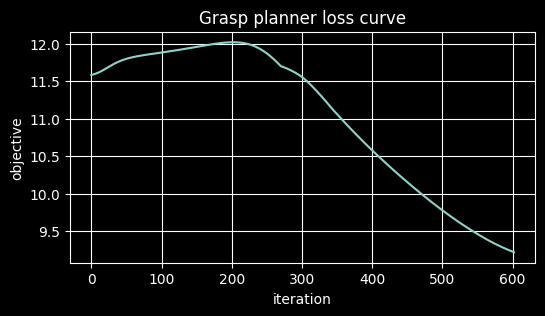

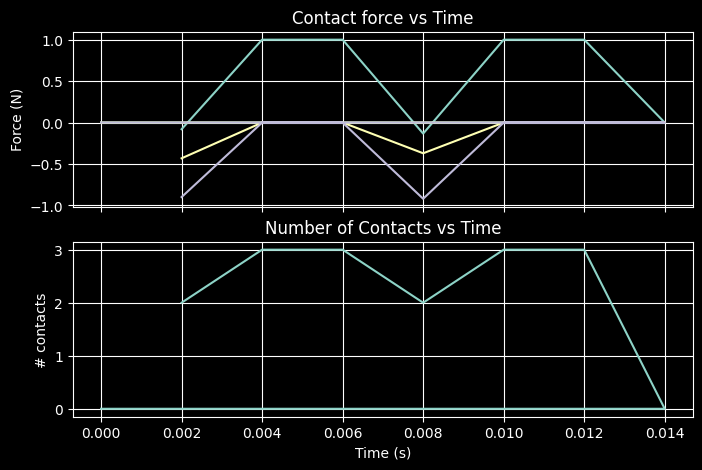

(d) No precomputed Q+/Q- table found. Compute it once in a separate cell and store as `q_table_df`.


In [92]:
# Experimental results: plots/tables for grasping deliverables
# Plot-only cell: reuses data already computed in earlier cells.

import numpy as np
import matplotlib.pyplot as plt
from grasp_synthesis import joint_space_objective

# (b) Grasp planner: loss curve for the objective over time
# Uses `grasp_history` from cell 9 (list of q_h vectors).
try:
    if "grasp_history" in globals() and isinstance(grasp_history, (list, tuple)) and len(grasp_history) > 0:
        losses = [joint_space_objective(allegro_env, qh, fingertip_names, in_contact=False) for qh in grasp_history]
        plt.figure(figsize=(6, 3))
        plt.plot(losses)
        plt.title("Grasp planner loss curve")
        plt.xlabel("iteration")
        plt.ylabel("objective")
        plt.grid(True)
        plt.show()
    else:
        print("(b) No `grasp_history` found. In cell 9, run synthesize_grasp(..., return_history=True) and save the history as `grasp_history`.")
except Exception as e:
    print("(b) Could not plot loss curve:", e)


# (e) Contact force vs. Time and Number of Contacts vs. Time
# Uses arrays produced by your control-loop cell.
try:
    fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 5))

    ax[0].plot(sim_time, force)
    ax[0].set_title("Contact force vs Time")
    ax[0].set_ylabel("Force (N)")
    ax[0].grid(True)

    ax[1].plot(sim_time, ncon)
    ax[1].set_title("Number of Contacts vs Time")
    ax[1].set_ylabel("# contacts")
    ax[1].set_xlabel("Time (s)")
    ax[1].grid(True)

    plt.show()
except Exception as e:
    print("(e) Could not plot contact force/contacts vs time:", e)


# (d) Q+/Q- sweep table
# This inherently requires multiple grasp runs. If you already computed it, store it as a DataFrame
# named `q_table_df` (or `q_table_rows`) in a separate cell and this will just display it.
try:
    if "q_table_df" in globals():
        display(q_table_df)
    elif "q_table_rows" in globals():
        import pandas as pd
        display(pd.DataFrame(q_table_rows))
    else:
        print("(d) No precomputed Q+/Q- table found. Compute it once in a separate cell and store as `q_table_df`.")
except Exception as e:
    print("(d) Could not display Q+/Q- table:", e)
